# Análise Exploratória de Dados — House Prices

**Dataset:** `treino.csv` — 1.168 imóveis residenciais em Ames, Iowa (EUA)  
**Objetivo:** Entender a distribuição dos dados, identificar padrões, tratar nulos e outliers, e preparar o dataset limpo para modelagem.  
**Métrica alvo:** RMSLE (Root Mean Squared Log Error)

---

## 0. Imports e Configurações

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

## 1. Carregamento dos Dados

In [4]:
df = pd.read_csv('../data/treino.csv')

print(f'Shape: {df.shape}')
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
print(f'\nTipos de dados:')
print(df.dtypes.value_counts())

Shape: (1168, 81)
Linhas: 1168 | Colunas: 81

Tipos de dados:
object     43
int64      35
float64     3
Name: count, dtype: int64


In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.00,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1957,1957,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,Gd,CBlock,TA,TA,No,Rec,922,Unf,0,392,1314,GasA,TA,Y,SBrkr,1314,0,0,1314,1,0,1,0,3,1,TA,5,Typ,0,NaN,Attchd,1957.00,RFn,1,294,TA,TA,Y,250,0,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.00,7837,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,7,1993,1994,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,799,799,GasA,Gd,Y,SBrkr,799,772,0,1571,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1993.00,RFn,2,380,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.00,8777,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,Norm,1Fam,1Story,5,7,1910,1950,Gable,CompShg,MetalSd,Wd Sdng,NaN,0.00,TA,TA,CBlock,Fa,TA,No,Unf,0,Unf,0,796,796,GasA,Gd,Y,FuseA,796,0,0,796,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,P,328,0,164,0,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.00,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Feedr,Norm,1Fam,1.5Fin,5,7,1937,1950,Gable,CompShg,Wd Sdng,Wd Sdng,BrkFace,252.00,TA,TA,BrkTil,Gd,TA,No,ALQ,569,Unf,0,162,731,GasA,Ex,Y,SBrkr,981,787,0,1768,1,0,1,1,3,1,Gd,7,Typ,2,TA,Detchd,1939.00,Unf,1,240,TA,TA,Y,0,0,264,0,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.00,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,Norm,1Fam,1.5Fin,5,6,1924,1950,Gable,CompShg,BrkFace,Wd Sdng,NaN,0.00,TA,TA,BrkTil,TA,TA,No,LwQ,218,Unf,0,808,1026,GasA,TA,Y,SBrkr,1026,665,0,1691,0,0,2,0,3,1,Gd,6,Typ,1,Gd,Detchd,1924.00,Unf,1,308,TA,TA,Y,0,0,242,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1168.00,1168.00,951.00,1168.00,1168.00,1168.00,1168.00,1168.00,1162.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1104.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00
mean,730.90,56.85,70.34,10689.64,6.12,5.58,1970.97,1984.90,103.77,446.02,45.15,570.60,1061.77,1169.35,352.35,5.70,1527.40,0.43,0.06,1.58,0.38,2.89,1.05,6.56,0.62,1978.66,1.78,476.27,95.95,49.58,21.84,3.81,15.41,2.96,51.27,6.36,2007.82,181441.54
std,425.37,42.53,24.90,10759.37,1.37,1.12,30.68,20.73,173.03,459.07,158.22,446.36,440.68,386.68,439.57,47.89,524.43,0.52,0.24,0.55,0.50,0.80,0.23,1.62,0.65,24.73,0.74,211.10,129.69,69.43,62.08,31.52,55.88,41.65,553.04,2.67,1.32,77263.58
min,1.00,20.00,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,0.00,0.00,0.00,334.00,0.00,0.00,334.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,1900.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,34900.00
25%,360.75,20.00,59.00,7587.25,5.00,5.00,1953.00,1966.00,0.00,0.00,0.00,222.50,796.00,888.00,0.00,0.00,1145.75,0.00,0.00,1.00,0.00,2.00,1.00,5.00,0.00,1961.75,1.00,341.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00,130000.00
50%,732.50,50.00,70.00,9600.00,6.00,5.00,1972.00,1994.00,0.00,384.50,0.00,480.00,997.50,1095.00,0.00,0.00,1473.00,0.00,0.00,2.00,0.00,3.00,1.00,6.00,1.00,1980.00,2.00,482.00,0.00,27.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,165000.00
75%,1101.75,70.00,80.00,11700.00,7.00,6.00,2001.00,2004.00,166.00,721.00,0.00,810.25,1299.25,1396.75,728.00,0.00,1792.00,1.00,0.00,2.00,1.00,3.00,1.00,7.00,1.00,2002.00,2.00,576.00,168.00,74.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,214925.00
max,1460.00,190.00,313.00,215245.00,10.00,9.00,2010.00,2010.00,1378.00,5644.00,1127.00,2336.00,6110.00,4692.00,2065.00,572.00,5642.00,3.00,2.00,3.00,2.00,8.00,3.00,14.00,3.00,2010.00,4.00,1418.00,857.00,547.00,552.00,508.00,480.00,738.00,15500.00,12.00,2010.00,745000.00


## 2. Análise da Variável Alvo — SalePrice

> A métrica RMSLE penaliza erros proporcionais. Aplicar `log1p` na variável alvo reduz a assimetria e força o modelo a otimizar proporções — essencial para bons resultados na competição.

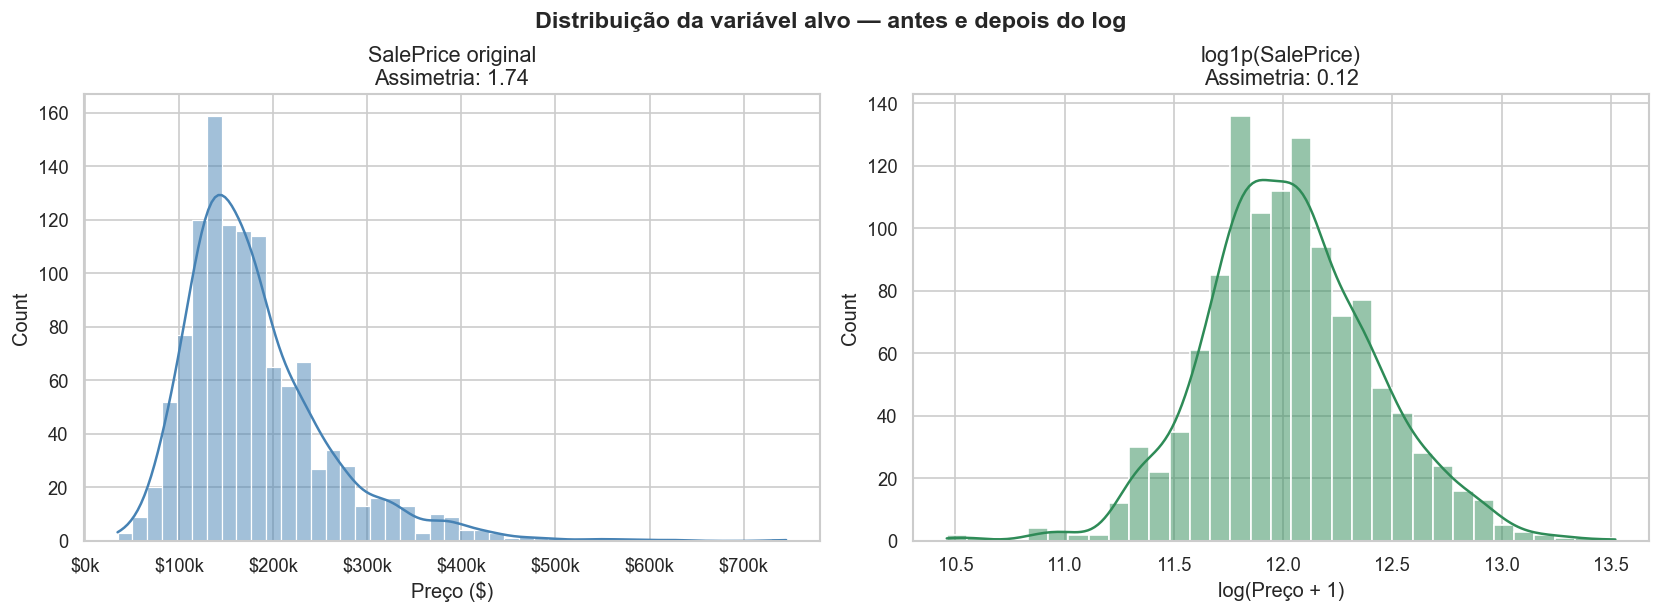

Estatísticas do SalePrice:
count      $1,168
mean     $181,442
std       $77,264
min       $34,900
25%      $130,000
50%      $165,000
75%      $214,925
max      $745,000
Name: SalePrice, dtype: object


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição original
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'SalePrice original\nAssimetria: {df["SalePrice"].skew():.2f}', fontsize=13)
axes[0].set_xlabel('Preço ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Distribuição com log1p
log_price = np.log1p(df['SalePrice'])
sns.histplot(log_price, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'log1p(SalePrice)\nAssimetria: {log_price.skew():.2f}', fontsize=13)
axes[1].set_xlabel('log(Preço + 1)')

plt.tight_layout()
plt.suptitle('Distribuição da variável alvo — antes e depois do log', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print(f'Estatísticas do SalePrice:')
print(df['SalePrice'].describe().apply(lambda x: f'${x:,.0f}'))

**Conclusão:** A distribuição original tem assimetria de +1.74 (cauda longa à direita). Após `log1p`, a assimetria cai para ~0.12 — praticamente normal. O modelo deve ser treinado com `log1p(SalePrice)` e as predições revertidas com `np.expm1()` no `pipeline.py`.

## 3. Análise de Correlações

> Identificar quais variáveis numéricas têm maior relação linear com o preço.

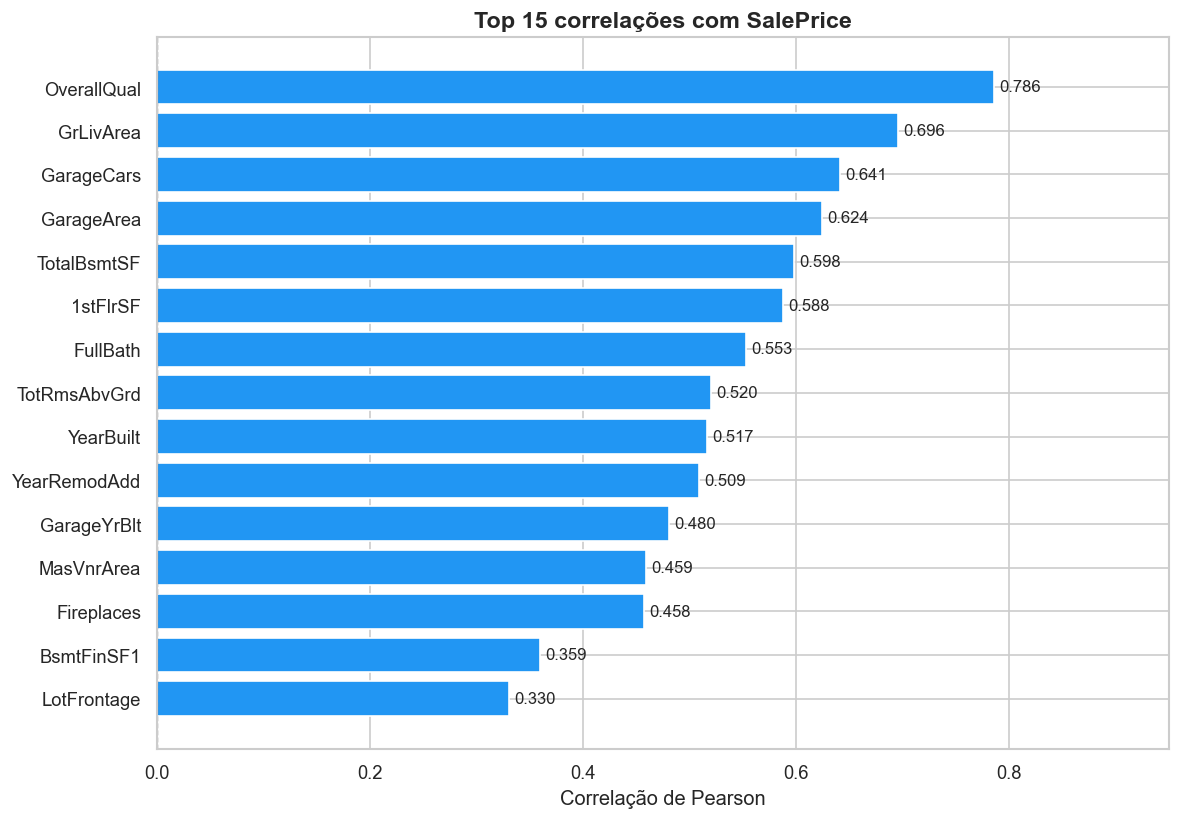


Top 10 positivas:
OverallQual    0.79
GrLivArea      0.70
GarageCars     0.64
GarageArea     0.62
TotalBsmtSF    0.60
1stFlrSF       0.59
FullBath       0.55
TotRmsAbvGrd   0.52
YearBuilt      0.52
YearRemodAdd   0.51
Name: SalePrice, dtype: float64

Top 5 negativas:
BsmtHalfBath    -0.05
OverallCond     -0.07
MSSubClass      -0.09
KitchenAbvGr    -0.14
EnclosedPorch   -0.15
Name: SalePrice, dtype: float64


In [8]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_with_price = df[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))

top15 = corr_with_price.head(15)
colors = ['#2196F3' if v > 0 else '#F44336' for v in top15.values]
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, top15.values[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Top 15 correlações com SalePrice', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlação de Pearson')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlim(0, 0.95)
plt.tight_layout()
plt.show()

print('\nTop 10 positivas:')
print(corr_with_price.head(10))
print('\nTop 5 negativas:')
print(corr_with_price.tail(5))

**Principais descobertas:**
- `OverallQual` (0.79): maior correlação isolada — qualidade geral é o fator decisivo
- `GrLivArea` (0.70): área habitável acima do térreo é o segundo fator mais importante  
- `GarageCars` e `GarageArea` (~0.63): tamanho da garagem importa bastante
- `TotalBsmtSF` e `1stFlrSF` (~0.59): tamanho do porão e primeiro andar também correlacionam bem
- `YearBuilt` e `YearRemodAdd` (~0.51): casas mais novas ou recentemente reformadas valem mais

## 4. Variáveis Categóricas Importantes

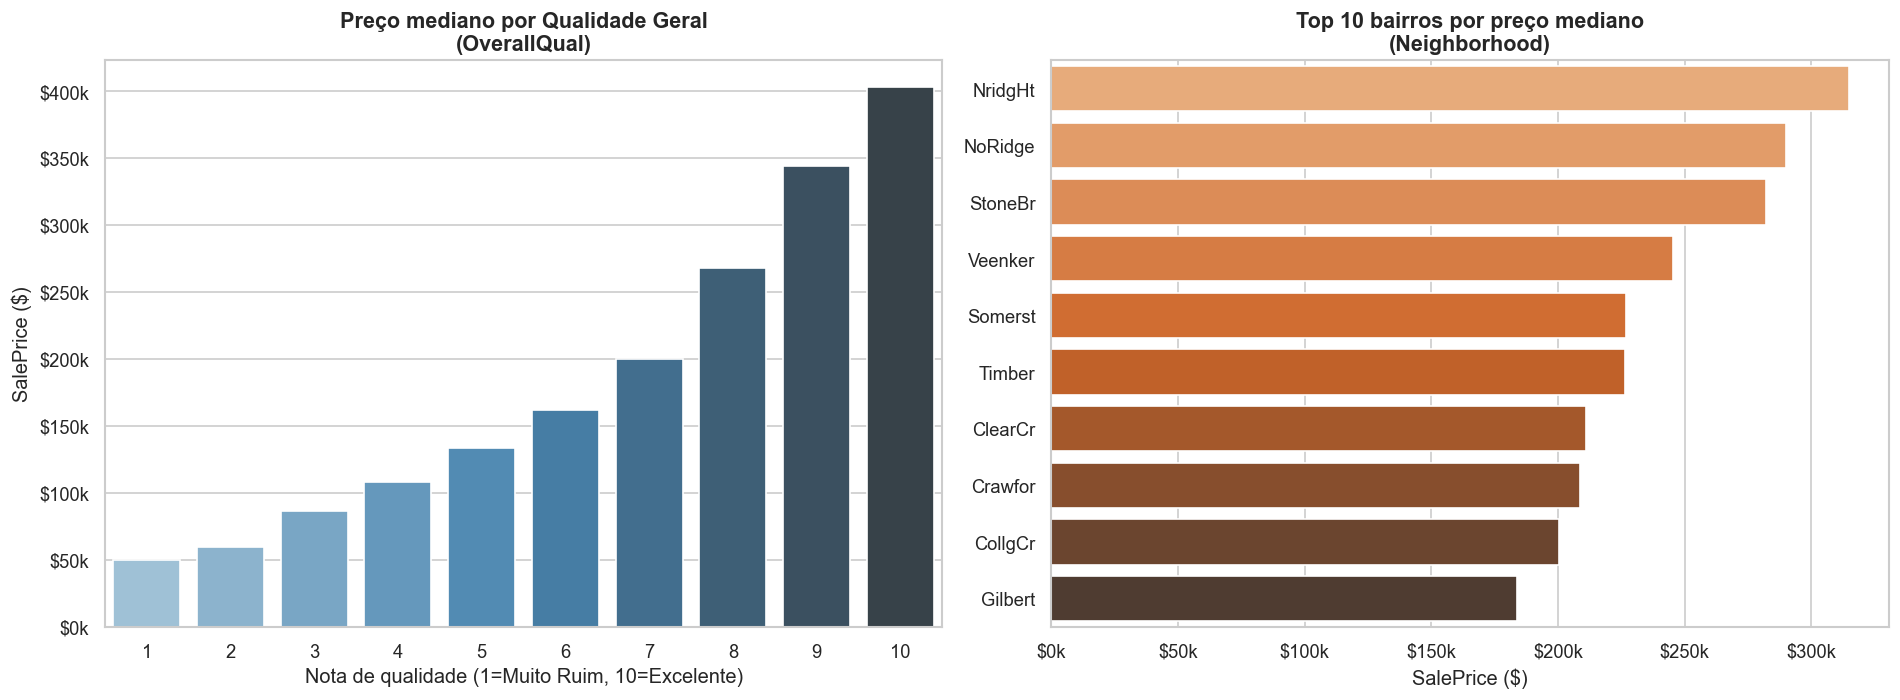

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Preço por OverallQual
qual_price = df.groupby('OverallQual')['SalePrice'].median().reset_index()
sns.barplot(data=qual_price, x='OverallQual', y='SalePrice', palette='Blues_d', ax=axes[0])
axes[0].set_title('Preço mediano por Qualidade Geral\n(OverallQual)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nota de qualidade (1=Muito Ruim, 10=Excelente)')
axes[0].set_ylabel('SalePrice ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Top 10 bairros por preço médio
neigh_price = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(10)
sns.barplot(x=neigh_price.values, y=neigh_price.index, palette='Oranges_d', ax=axes[1])
axes[1].set_title('Top 10 bairros por preço mediano\n(Neighborhood)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('SalePrice ($)')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

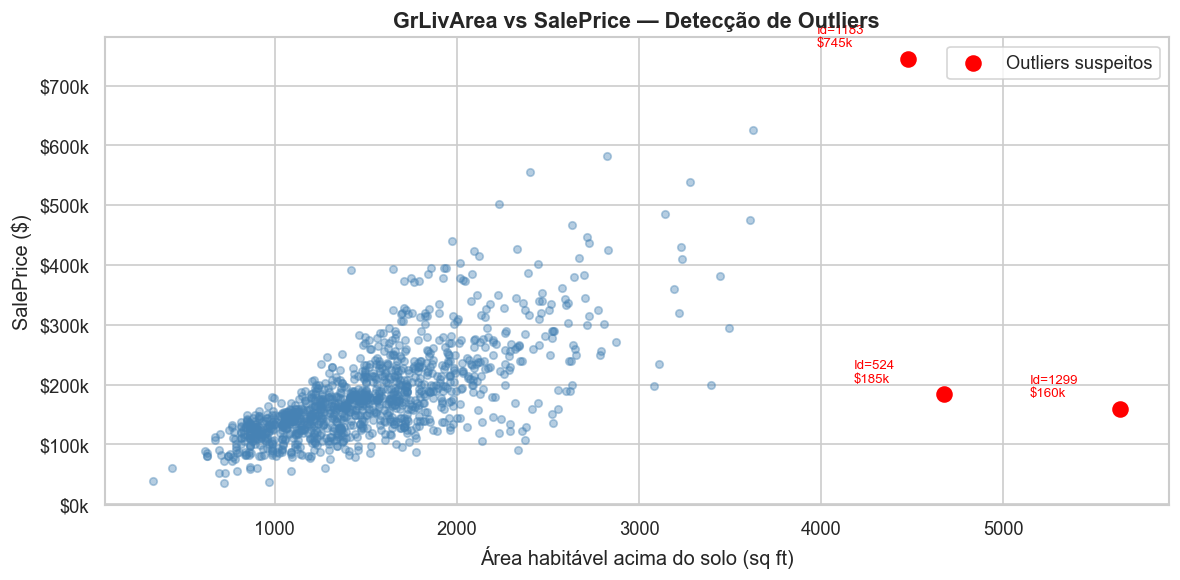

In [10]:
# Boxplot GrLivArea vs SalePrice
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='steelblue', s=20)
# Destacar outliers
outliers = df[df['GrLivArea'] > 4000]
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='red', s=80, zorder=5, label='Outliers suspeitos')
for _, row in outliers.iterrows():
    ax.annotate(f"Id={row['Id']}\n${row['SalePrice']/1000:.0f}k",
                xy=(row['GrLivArea'], row['SalePrice']),
                xytext=(row['GrLivArea']-500, row['SalePrice']+20000),
                fontsize=8, color='red')
ax.set_title('GrLivArea vs SalePrice — Detecção de Outliers', fontsize=13, fontweight='bold')
ax.set_xlabel('Área habitável acima do solo (sq ft)')
ax.set_ylabel('SalePrice ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

**Outliers detectados (GrLivArea > 4000 ft²):**
- **Id 524 e 1299:** Áreas enormes (4676 e 5642 ft²) vendidas por preços muito baixos (~$160-185k). São vendas atípicas que podem distorcer o modelo. Serão removidos no pré-processamento.
- **Id 1183:** Área grande (4476 ft²) com preço coerente ($745k). Será mantido.

## 5. Análise de Valores Nulos

> **Atenção crítica:** Neste dataset, muitos `NaN` têm significado de negócio (ausência de feature), não são dados perdidos. Verificar o dicionário de dados antes de qualquer imputação.

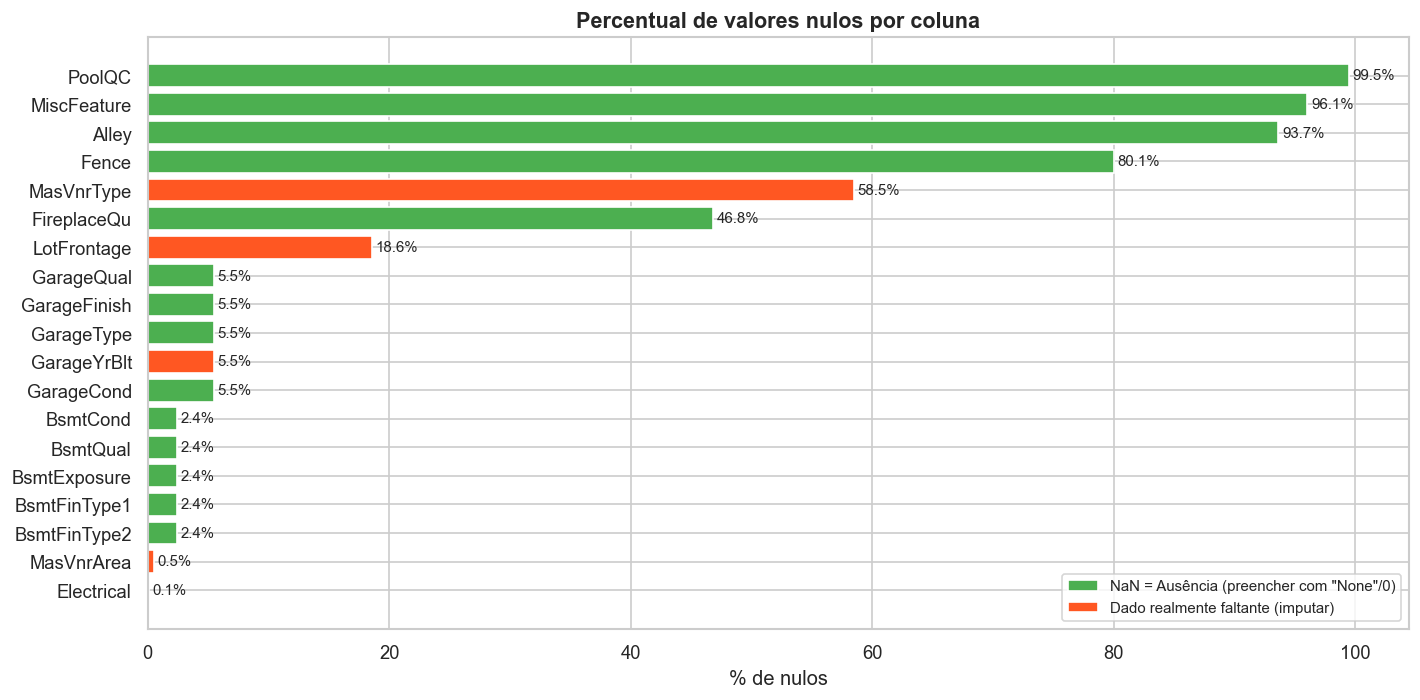

      Coluna  Percentual_Nulo                        Tipo
      PoolQC            99.49 ✅ NaN = Ausência da feature
 MiscFeature            96.06 ✅ NaN = Ausência da feature
       Alley            93.66 ✅ NaN = Ausência da feature
       Fence            80.05 ✅ NaN = Ausência da feature
  MasVnrType            58.48  ⚠️ Dado realmente faltante
 FireplaceQu            46.83 ✅ NaN = Ausência da feature
 LotFrontage            18.58  ⚠️ Dado realmente faltante
  GarageQual             5.48 ✅ NaN = Ausência da feature
GarageFinish             5.48 ✅ NaN = Ausência da feature
  GarageType             5.48 ✅ NaN = Ausência da feature
 GarageYrBlt             5.48  ⚠️ Dado realmente faltante
  GarageCond             5.48 ✅ NaN = Ausência da feature
    BsmtCond             2.40 ✅ NaN = Ausência da feature
    BsmtQual             2.40 ✅ NaN = Ausência da feature
BsmtExposure             2.40 ✅ NaN = Ausência da feature
BsmtFinType1             2.40 ✅ NaN = Ausência da feature
BsmtFinType2  

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_df = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['Coluna', 'Percentual_Nulo']

# Classificação: NaN com significado vs realmente faltante
nan_significa_ausencia = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]
missing_df['Tipo'] = missing_df['Coluna'].apply(
    lambda c: '✅ NaN = Ausência da feature' if c in nan_significa_ausencia else '⚠️ Dado realmente faltante'
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#4CAF50' if t.startswith('✅') else '#FF5722'
          for t in missing_df['Tipo']]
bars = ax.barh(missing_df['Coluna'][::-1], missing_df['Percentual_Nulo'][::-1],
               color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, missing_df['Percentual_Nulo'][::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('Percentual de valores nulos por coluna', fontsize=13, fontweight='bold')
ax.set_xlabel('% de nulos')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='NaN = Ausência (preencher com "None"/0)'),
                   Patch(facecolor='#FF5722', label='Dado realmente faltante (imputar)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print(missing_df.to_string(index=False))

## 6. Limpeza de Dados

### 6.1 Remover Outliers Extremos

In [12]:
print(f'Shape antes da remoção de outliers: {df.shape}')

# Remover as 2 casas com área gigante e preço inconsistente (Id 524 e 1299)
# Justificativa: GrLivArea > 4000 ft² com SalePrice < $200k indica venda atípica
# que distorceria a relação área-preço aprendida pelo modelo.
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))].copy()
df = df.reset_index(drop=True)

print(f'Shape após remoção de outliers: {df.shape}')
print(f'Linhas removidas: 2 (Id 524 e Id 1299)')

Shape antes da remoção de outliers: (1168, 81)
Shape após remoção de outliers: (1166, 81)
Linhas removidas: 2 (Id 524 e Id 1299)


### 6.2 Tratar Nulos com Significado de Negócio

Estas colunas têm NaN porque a casa **não possui** aquela feature (sem piscina, sem garagem, sem porão, etc). Preencher com `'None'` (categóricas) ou `0` (numéricas).

In [13]:
# --- Colunas categóricas onde NaN = Ausência da feature ---
cols_none = [
    # Piscina
    'PoolQC',
    # Misc
    'MiscFeature',
    # Acesso por beco
    'Alley',
    # Cerca
    'Fence',
    # Lareira
    'FireplaceQu',
    # Garagem
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    # Porão
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]

for col in cols_none:
    df[col] = df[col].fillna('None')

# --- Colunas numéricas onde NaN = 0 (sem garagem = 0 carros, 0 m²) ---
cols_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in cols_zero:
    df[col] = df[col].fillna(0)

print('Nulos tratados como ausência de feature: OK')

Nulos tratados como ausência de feature: OK


### 6.3 Tratar Nulos Realmente Faltantes

In [14]:
# LotFrontage (18.6% nulos): imputar pela mediana do bairro
# Justificativa: casas no mesmo bairro tendem a ter frentes de lote similares
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# MasVnrType (NaN = provavelmente sem revestimento)
df['MasVnrType'] = df['MasVnrType'].fillna('None')

# Electrical (apenas 1 nulo): preencher com moda
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
print(f'Electrical moda usada: {df["Electrical"].mode()[0]}')

# Verificar se ainda há nulos
remaining_nulls = df.isnull().sum()
print(f'\nNulos restantes: {remaining_nulls[remaining_nulls > 0]}')
print(f'Total de nulos no dataset: {df.isnull().sum().sum()}')

Electrical moda usada: SBrkr

Nulos restantes: Series([], dtype: int64)
Total de nulos no dataset: 0


### 6.4 Corrigir Tipos de Dados

`MSSubClass` é um código numérico que representa **categorias** de imóveis — não faz sentido tratar como número contínuo.

In [15]:
# MSSubClass: código numérico que representa tipo de imóvel (deve ser categórico)
df['MSSubClass'] = df['MSSubClass'].astype(str)

# YrSold e MoSold: podem ser tratados como categóricos também
df['YrSold'] = df['YrSold'].astype(str)
df['MoSold'] = df['MoSold'].astype(str)

print('Tipos corrigidos: MSSubClass, YrSold, MoSold → string/categórico')

Tipos corrigidos: MSSubClass, YrSold, MoSold → string/categórico


### 6.5 Encoding Ordinal de Variáveis de Qualidade

Colunas de qualidade (Ex / Gd / TA / Fa / Po / None) têm ordem lógica. Convertemos para números para que o modelo capture essa hierarquia.

In [16]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

qual_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC'
]

for col in qual_cols:
    df[col] = df[col].map(qual_map)

# BsmtExposure
df['BsmtExposure'] = df['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})

# BsmtFinType1 e 2
bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fin_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fin_map)

# GarageFinish
df['GarageFinish'] = df['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})

# Functional
func_map = {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7}
df['Functional'] = df['Functional'].map(func_map)

# PavedDrive
df['PavedDrive'] = df['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})

print('Encoding ordinal aplicado nas variáveis de qualidade.')
print('Exemplo BsmtQual:', df['BsmtQual'].value_counts().head())

Encoding ordinal aplicado nas variáveis de qualidade.
Exemplo BsmtQual: BsmtQual
3    521
4    493
5     95
2     29
0     28
Name: count, dtype: int64


## 7. Feature Engineering

> Criar novas variáveis que capturam informações que os modelos não conseguiriam extrair diretamente das colunas originais.

In [17]:
# Idade da casa no momento da venda
df['house_age'] = df['YrSold'].astype(int) - df['YearBuilt']

# Anos desde a última reforma
df['years_since_remod'] = df['YrSold'].astype(int) - df['YearRemodAdd']

# A casa foi reformada? (1 = sim, 0 = não)
df['was_remodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

# Área total do imóvel (térreo + 1º + 2º andar)
df['total_sf'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# Total de banheiros
df['total_bathrooms'] = (df['FullBath'] + df['BsmtFullBath']
                         + 0.5 * df['HalfBath'] + 0.5 * df['BsmtHalfBath'])

# Área de varanda/pórtico total
df['total_porch_sf'] = (df['OpenPorchSF'] + df['EnclosedPorch']
                        + df['3SsnPorch'] + df['ScreenPorch'])

# A casa tem piscina? (1 = sim)
df['has_pool'] = (df['PoolArea'] > 0).astype(int)

# A casa tem lareira? (1 = sim)
df['has_fireplace'] = (df['Fireplaces'] > 0).astype(int)

# A casa tem garagem? (1 = sim)
df['has_garage'] = (df['GarageArea'] > 0).astype(int)

print('Features criadas:', ['house_age', 'years_since_remod', 'was_remodeled',
                             'total_sf', 'total_bathrooms', 'total_porch_sf',
                             'has_pool', 'has_fireplace', 'has_garage'])

# Verificar correlação das novas features com SalePrice
new_feats = ['house_age', 'years_since_remod', 'was_remodeled',
             'total_sf', 'total_bathrooms', 'total_porch_sf']
print('\nCorrelação das novas features com SalePrice:')
print(df[new_feats + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False))

Features criadas: ['house_age', 'years_since_remod', 'was_remodeled', 'total_sf', 'total_bathrooms', 'total_porch_sf', 'has_pool', 'has_fireplace', 'has_garage']

Correlação das novas features com SalePrice:
total_sf             0.83
total_bathrooms      0.63
total_porch_sf       0.18
was_remodeled       -0.03
years_since_remod   -0.51
house_age           -0.52
Name: SalePrice, dtype: float64


## 8. Análise de Assimetria em Colunas Numéricas

> Colunas com alta assimetria podem prejudicar modelos lineares. Aplicar `log1p` nas mais assimétricas.

In [19]:
from scipy.stats import skew

num_feats = df.select_dtypes(include=np.number).columns.drop(['Id', 'SalePrice'])
skewness = df[num_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

# Aplicar log1p em colunas com assimetria > 0.75
skewed_feats = skewness[skewness > 0.75].index.tolist()
print(f'Colunas com assimetria > 0.75: {len(skewed_feats)}')
print(skewed_feats)

for feat in skewed_feats:
    df[feat] = np.log1p(df[feat])

print('\nTransformação log1p aplicada.')

Colunas com assimetria > 0.75: 26
['MiscVal', 'PoolQC', 'PoolArea', 'has_pool', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath', 'BsmtFinType2', 'EnclosedPorch', 'OpenPorchSF', 'MasVnrArea', 'total_porch_sf', 'LotFrontage', 'WoodDeckSF', 'ExterCond', 'BsmtExposure', 'GrLivArea', 'BsmtUnfSF', 'ExterQual', '1stFlrSF', '2ndFlrSF', 'total_sf']

Transformação log1p aplicada.


## 9. Salvando o Dataset Limpo

In [20]:
# Remover a coluna Id (não é uma feature)
df_clean = df.drop(columns=['Id']).copy()

# Salvar
df_clean.to_csv('../data/treino_limpo.csv', index=False)

print(f'Dataset limpo salvo em: data/treino_limpo.csv')
print(f'Shape final: {df_clean.shape}')
print(f'Nulos restantes: {df_clean.isnull().sum().sum()}')
print(f'\nColunas numéricas: {df_clean.select_dtypes(include=np.number).shape[1]}')
print(f'Colunas categóricas: {df_clean.select_dtypes(include="object").shape[1]}')

Dataset limpo salvo em: data/treino_limpo.csv
Shape final: (1166, 89)
Nulos restantes: 0

Colunas numéricas: 59
Colunas categóricas: 30


## 10. Resumo das Decisões Tomadas

| Ação | Colunas afetadas | Justificativa |
|------|-----------------|---------------|
| Remoção de outliers | 2 linhas (Id 524, 1299) | GrLivArea gigante com preço inconsistente |
| Preenchimento `'None'` | 14 colunas categóricas | NaN = ausência da feature no imóvel |
| Preenchimento `0` | 10 colunas numéricas | NaN = 0 m² / 0 carros (sem garagem/porão) |
| Imputação por mediana do bairro | `LotFrontage` | Casas do mesmo bairro têm frentes similares |
| Imputação por moda | `Electrical` | Apenas 1 nulo |
| Conversão para string | `MSSubClass`, `YrSold`, `MoSold` | São categorias, não números contínuos |
| Encoding ordinal | 10+ colunas de qualidade | Preserva a hierarquia Ex > Gd > TA > Fa > Po |
| Feature engineering | 9 novas colunas | Capturam idade, reforma, área total, banheiros |
| Transformação `log1p` | Colunas com skew > 0.75 | Reduz assimetria para modelos lineares |
| `log1p(SalePrice)` | Variável alvo | Otimiza RMSLE diretamente |

> **Próximo passo:** Notebook `02_modelagem.ipynb` — Testar Regressão Linear, Random Forest e XGBoost com este dataset limpo.